In [1]:
suppressPackageStartupMessages({
    library(ArchR) 
    library(data.table)
    library(purrr)
    library(parallel)
    library(dplyr)
    library(ggpubr)
    library(Matrix)
    library(SingleCellExperiment)
    library(Seurat)
    library(reshape2)
    library(scater)
    library(viridis)
})

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
# I/O
io = list()
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2'
io$output.directory <- file.path(io$basedir,"ArchR")
io$plot.dir = file.path(io$output.directory,'Plots')

setwd(io$output.directory)

In [3]:
io$archR.directory = file.path(io$output.directory, 'Project/')
ArchRProject.filt = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [7]:
addArchRGenome("mm10")

Setting default genome to Mm10.



In [19]:
test = getArchRGenome(geneAnnotation  = TRUE)

Using GeneAnnotation set by addArchRGenome(Mm10)!



In [23]:
test$TSS

GRanges object with 45199 ranges and 2 metadata columns:
          seqnames    ranges strand |     tx_id     tx_name
             <Rle> <IRanges>  <Rle> | <integer> <character>
      [1]     chr1   4807893      + |         1  uc007afg.1
      [2]     chr1   4857694      + |         3  uc007afi.2
      [3]     chr1   4858328      + |         5  uc011whu.1
      [4]     chr1   4884322      + |         6  uc057aty.1
      [5]     chr1   5083086      + |         7  uc007afm.2
      ...      ...       ...    ... .       ...         ...
  [45195]     chrY  89745342      - |     63557  uc029ygr.1
  [45196]     chrY  89745550      - |     63559  uc029ygt.1
  [45197]     chrY  90531635      - |     63560  uc029ygu.1
  [45198]     chrY  90605864      - |     63561  uc029ygv.1
  [45199]     chrY  90755050      - |     63562  uc057mdi.1
  -------
  seqinfo: 21 sequences from mm10 genome

In [9]:
ArchRProject.filt@geneAnnotation$TSS

GRanges object with 38003 ranges and 2 metadata columns:
                     seqnames    ranges strand |     tx_id            tx_name
                        <Rle> <IRanges>  <Rle> | <integer>        <character>
  ENSOCUG00000014251     chr1     15188      + |         1 ENSOCUT00000014253
  ENSOCUG00000014251     chr1     20324      + |         2 ENSOCUT00000038745
  ENSOCUG00000005054     chr1     52453      + |         3 ENSOCUT00000005053
  ENSOCUG00000005044     chr1     75200      + |         4 ENSOCUT00000005041
  ENSOCUG00000005028     chr1    125890      + |         5 ENSOCUT00000005032
                 ...      ...       ...    ... .       ...                ...
  ENSOCUG00000000255     chrX 111369675      - |     37999 ENSOCUT00000000255
  ENSOCUG00000007220     chrX 111496239      - |     38000 ENSOCUT00000007220
  ENSOCUG00000019315     chrX 111494835      - |     38001 ENSOCUT00000019315
  ENSOCUG00000022547     chrX 111532815      - |     38002 ENSOCUT00000023399
  ENSOC

In [7]:
ArchRProject.filt@geneAnnotation$exons

GRanges object with 175810 ranges and 3 metadata columns:
           seqnames              ranges strand |   exon_id            gene_id
              <Rle>           <IRanges>  <Rle> | <integer>        <character>
       [1]     chr1         15188-15281      + |         1 ENSOCUG00000014251
       [2]     chr1         20324-20325      + |         2 ENSOCUG00000014251
       [3]     chr1         20453-20602      + |         3 ENSOCUG00000014251
       [4]     chr1         20453-20602      + |         4 ENSOCUG00000014251
       [5]     chr1         21033-21162      + |         5 ENSOCUG00000014251
       ...      ...                 ...    ... .       ...                ...
  [175806]     chrX 111494764-111494835      - |    175806 ENSOCUG00000007220
  [175807]     chrX 111494883-111495010      - |    175807 ENSOCUG00000007220
  [175808]     chrX 111496121-111496239      - |    175808 ENSOCUG00000007220
  [175809]     chrX 111532709-111532815      - |    175809 ENSOCUG00000022547
  [175

In [8]:
ArchRProject.filt@geneAnnotation$TSS

GRanges object with 38003 ranges and 2 metadata columns:
                     seqnames    ranges strand |     tx_id            tx_name
                        <Rle> <IRanges>  <Rle> | <integer>        <character>
  ENSOCUG00000014251     chr1     15188      + |         1 ENSOCUT00000014253
  ENSOCUG00000014251     chr1     20324      + |         2 ENSOCUT00000038745
  ENSOCUG00000005054     chr1     52453      + |         3 ENSOCUT00000005053
  ENSOCUG00000005044     chr1     75200      + |         4 ENSOCUT00000005041
  ENSOCUG00000005028     chr1    125890      + |         5 ENSOCUT00000005032
                 ...      ...       ...    ... .       ...                ...
  ENSOCUG00000000255     chrX 111369675      - |     37999 ENSOCUT00000000255
  ENSOCUG00000007220     chrX 111496239      - |     38000 ENSOCUT00000007220
  ENSOCUG00000019315     chrX 111494835      - |     38001 ENSOCUT00000019315
  ENSOCUG00000022547     chrX 111532815      - |     38002 ENSOCUT00000023399
  ENSOC

In [4]:
getAvailableMatrices(ArchRProject.filt)

[1] "GeneIntegrationMatrix" "GeneScoreMatrix"       "MotifMatrix"          
[4] "PeakMatrix"            "TileMatrix"

In [8]:
## START TEST ##
args <- list()
args$metadata <- file.path(io$output.directory, 'metadata_qc.txt.gz')
args$nfeatures <- 15000
args$matrix <- 'PeakMatrix' #"GeneScoreMatrix"
args$ndims <- 25
args$seed <- 42
args$n_neighbors <- 25
args$min_dist <- 0.4
args$vars_to_regress <- NULL #c("nFeature_RNA","mitochondrial_percent_RNA")
args$outdir <- paste0(io$basedir,"/dimensionality_reduction")
args$batch.variable = 'sample'
args$colour_by <- c("sample", "cluster")


# Options
opts = list()
opts$lsi.iterations = 2
opts$lsi.cluster.resolution = 1.5

In [9]:
test = ArchRProject.filt 

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-29049337176ae-Date-2021-12-06_Time-12-00-45.log
If there is an issue, please report to github with logFile!

2021-12-06 12:00:46 : Computing Total Across All Features, 0.007 mins elapsed.

2021-12-06 12:00:55 : Computing Top Features, 0.15 mins elapsed.

###########
2021-12-06 12:00:56 : Running LSI (1 of 2) on Top Features, 0.162 mins elapsed.
###########

2021-12-06 12:00:56 : Sampling Cells (N = 10004) for Estimated LSI, 0.163 mins elapsed.

2021-12-06 12:00:56 : Creating Sampled Partial Matrix, 0.163 mins elapsed.

2021-12-06 12:01:41 : Computing Estimated LSI (projectAll = FALSE), 0.916 mins elapsed.

2021-12-06 12:01:54 : Identifying Clusters, 1.132 mins elapsed.

Warning message:
“The following arguments are not used: row.names”
2021-12-06 12:02:08 : Identified 6 Clusters, 1.368 mins elapsed.

2021-12-06 12:02:08 : Creating Cluster Matrix on the total Group Features, 1.368 mins elapsed.

2021-12-06 12:03:16 :

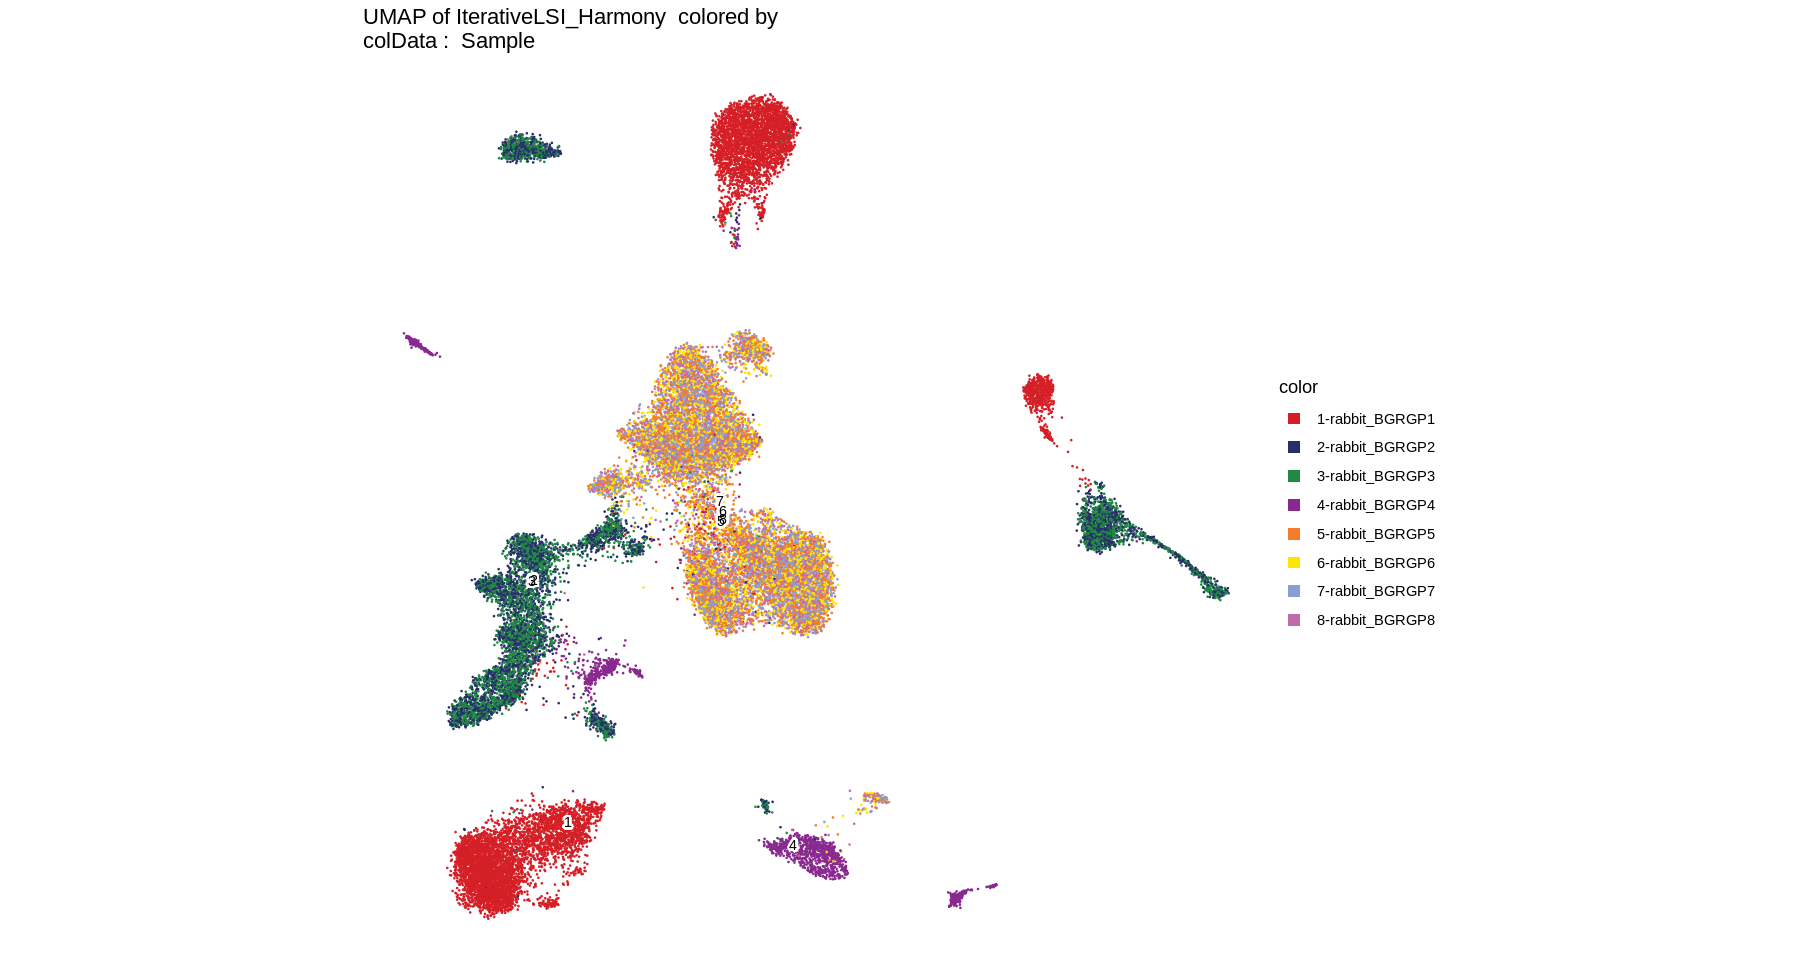

In [10]:
test <- addIterativeLSI(
  ArchRProj = test,
  useMatrix = args$matrix, 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  force = TRUE,
  outDir = args$outdir
)

test <- addHarmony(
  ArchRProj = test,
  reducedDims = "IterativeLSI",
  name = "IterativeLSI_Harmony",
  groupBy = args$batch.variable,
  force = TRUE
)

# Run UMAP
test <- addUMAP(
  ArchRProj = test, 
  reducedDims = 'IterativeLSI_Harmony',
  name = "UMAP",
  metric = "cosine",
  nNeighbors = args$n_neighbors, 
  minDist = args$min_dist, 
  seed = args$seed,
  saveModel = FALSE,
  force = TRUE
)

plotEmbedding(test) + theme_void()

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-29049657214b9-Date-2021-12-06_Time-12-36-35.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 

Length of unique values greater than palette, interpolating..



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-29049657214b9-Date-2021-12-06_Time-12-36-35.log



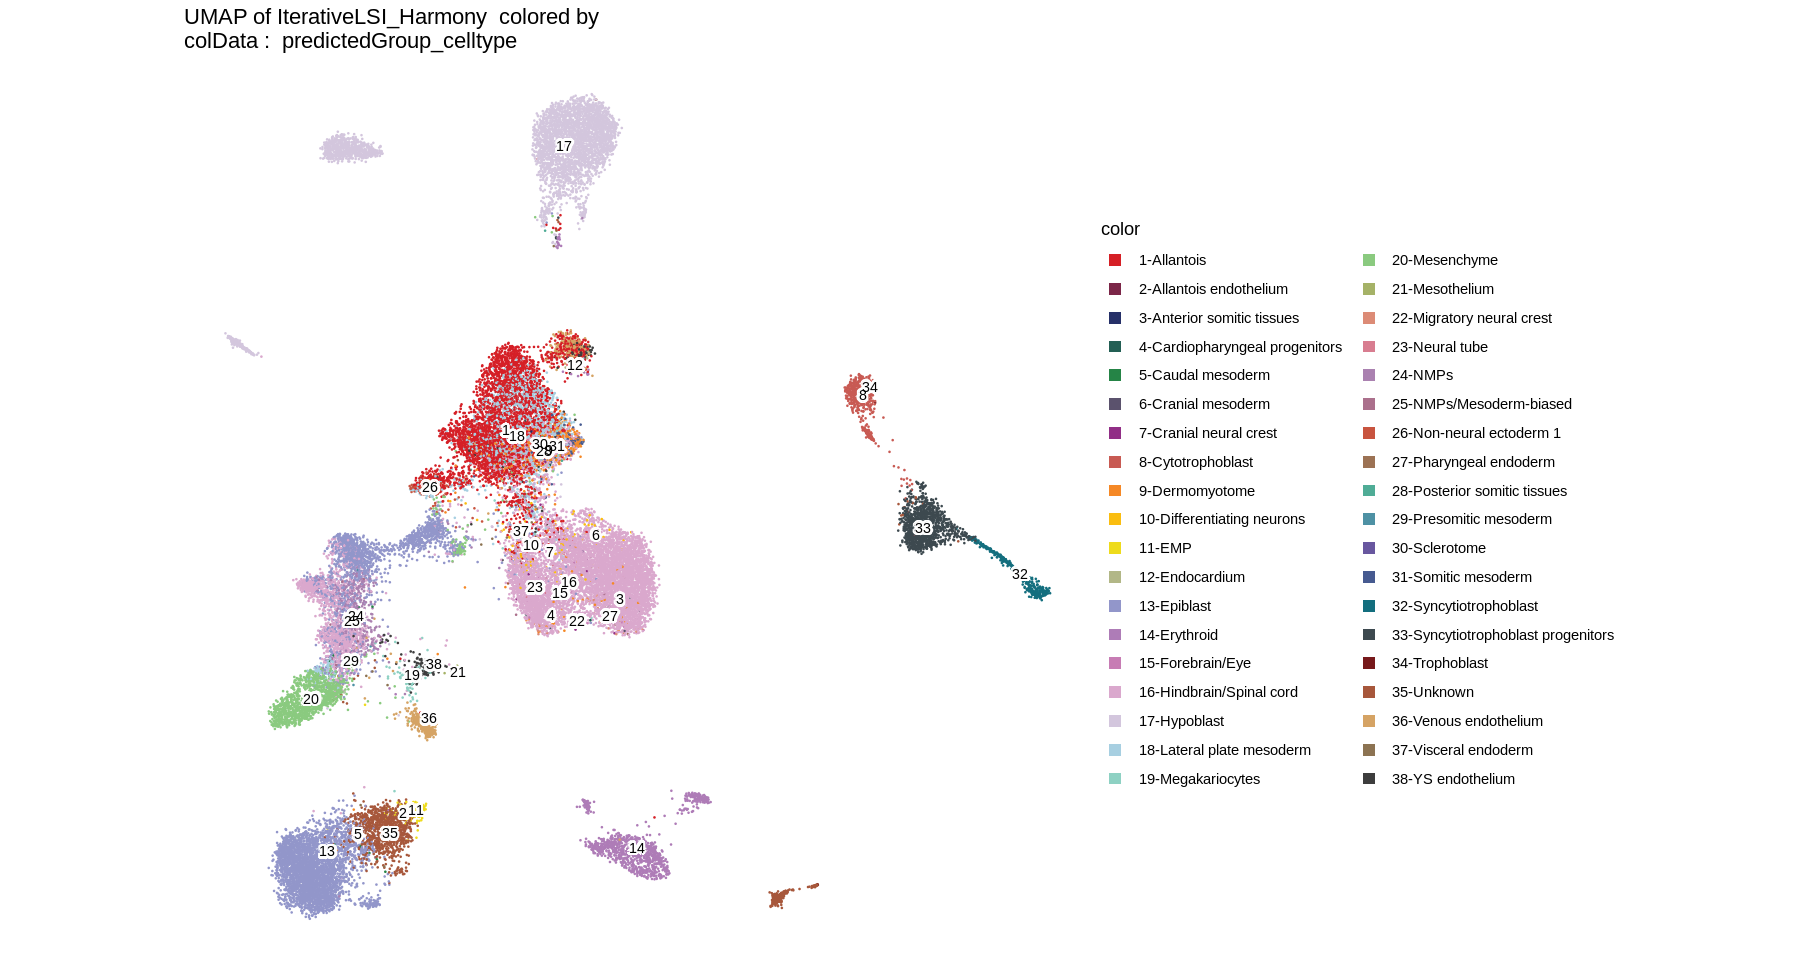

In [13]:
plotEmbedding(test,colorBy = "cellColData",
  name = "predictedGroup_celltype",) + theme_void()

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-290496042d76f-Date-2021-12-06_Time-12-40-11.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 



ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-290496042d76f-Date-2021-12-06_Time-12-40-11.log



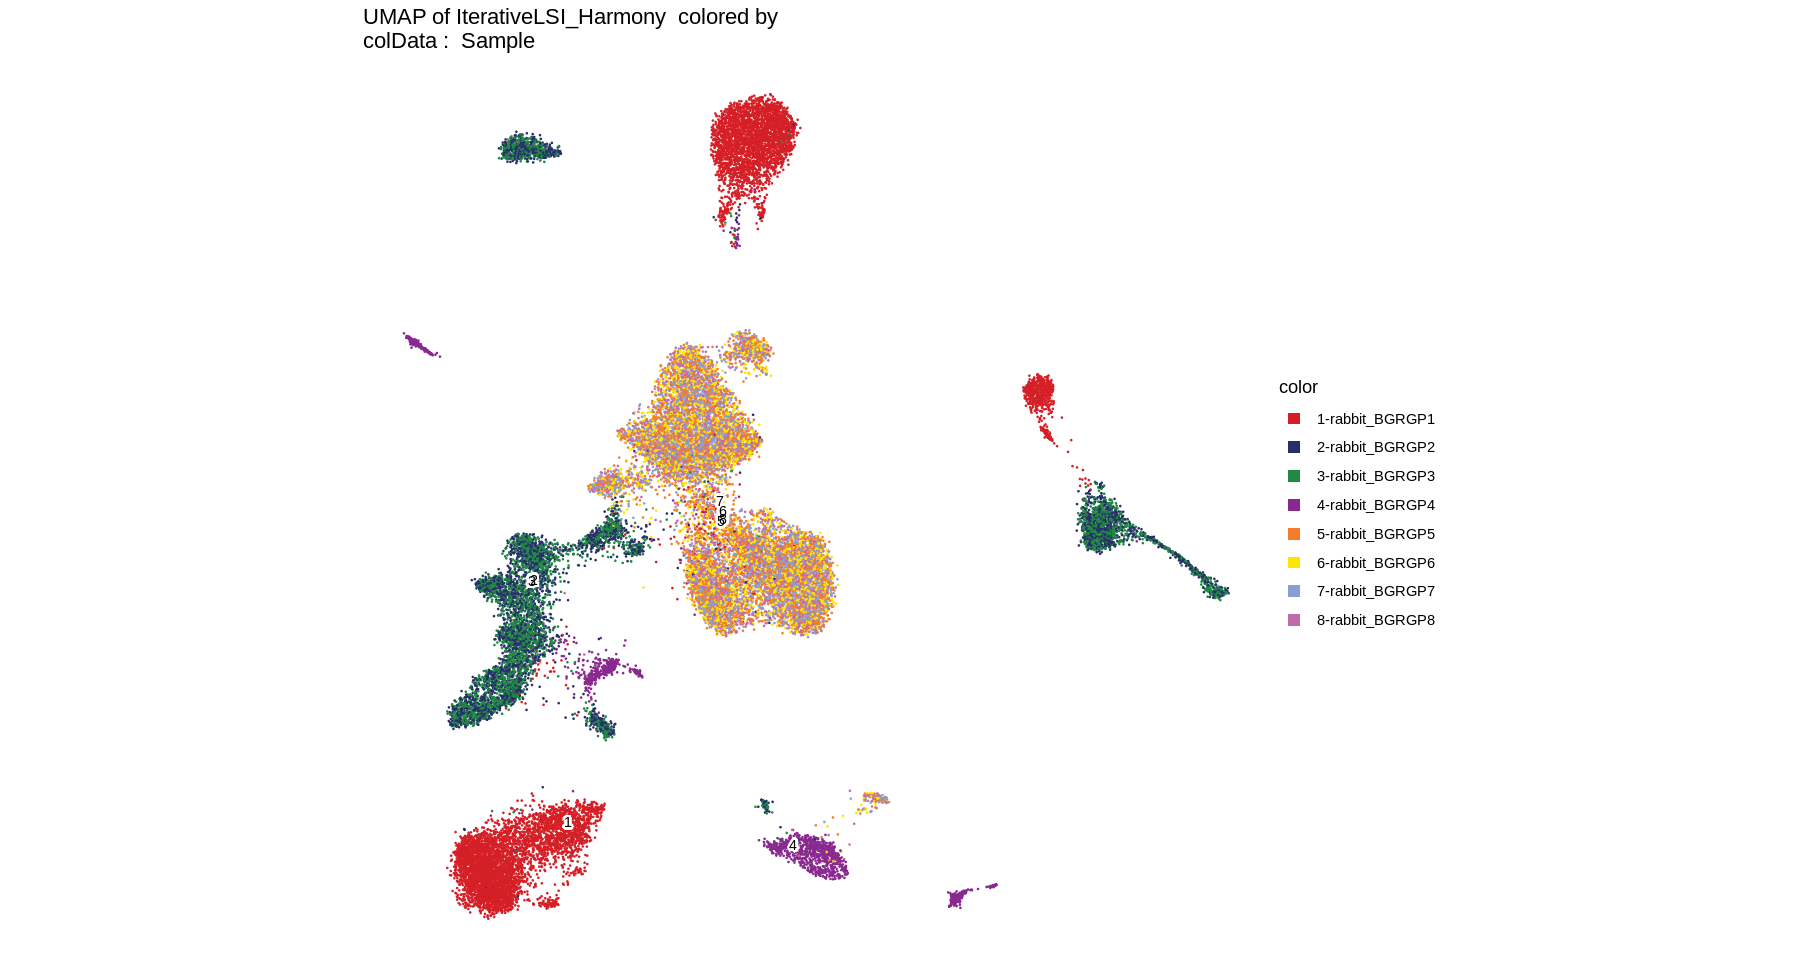

In [14]:
plotEmbedding(test,colorBy = "cellColData",
  name = "Sample",) + theme_void()

In [11]:
args$matrix <- 'MotifMatrix' #"GeneScoreMatrix"

test <- addIterativeLSI(
  ArchRProj = test,
  useMatrix = args$matrix, 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  force = TRUE,
  outDir = args$outdir
)

test <- addHarmony(
  ArchRProj = test,
  reducedDims = "IterativeLSI",
  name = "IterativeLSI_Harmony",
  groupBy = args$batch.variable,
  force = TRUE
)

# Run UMAP
test <- addUMAP(
  ArchRProj = test, 
  reducedDims = 'IterativeLSI_Harmony',
  name = "UMAP",
  metric = "cosine",
  nNeighbors = args$n_neighbors, 
  minDist = args$min_dist, 
  seed = args$seed,
  saveModel = FALSE,
  force = TRUE
)

plotEmbedding(test) + theme_void()

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-290493ee267e3-Date-2021-12-06_Time-12-05-52.log
If there is an issue, please report to github with logFile!



ERROR: Error in addIterativeLSI(ArchRProj = test, useMatrix = args$matrix, name = "IterativeLSI", : Units of matrices are not identical!
